# Las 140 corridas del pipeline combinatorio

La guía (§2) pide recorrer el producto completo de modelos, técnicas de balanceo y métodos de
optimización: 7 clasificadores × 4 balanceos × 4 optimizadores = 112 corridas y 7 regresores × 4
optimizadores = 28, **140 en total**, automatizadas y registradas en una tabla maestra. Cada corrida
es una validación cruzada anidada completa (5 pliegues externos × 3 internos): la búsqueda de
hiperparámetros ocurre dentro de cada pliegue externo y la métrica reportada sale solo del bucle
externo. Al terminar, la búsqueda se repite sobre todo el entrenamiento para obtener el modelo final
y sus hiperparámetros, que se guardan en disco para la evaluación en prueba.

La clasificación usa la etiqueta del percentil 75 (25 % de clientes de riesgo alto, umbral estimado
solo con entrenamiento), para que las técnicas de balanceo tengan sentido; la regresión, el objetivo
continuo `churn_probability`. Las corridas se ejecutaron con `correr_140.py` entre el 29 de
septiembre y el 1 de octubre de 2026, y el modelo nuevo (la EBM) se añadió después con el mismo
lanzador y las mismas reglas.

In [1]:
import sys
import warnings
from pathlib import Path

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src import analisis, graficos
from src import estadistica as est
from src.analisis import NOMBRES_MODELO
from src.formato import dec, ent, enumerar, p_valor, pct

graficos.estilo()
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')
pd.set_option('display.max_colwidth', 120)

tabla = analisis.cargar_tabla()
ok = tabla[tabla['estado'] == 'ok']
guia = tabla[tabla['modelo'] != 'ebm']
print('estado de la tabla maestra:')
print(tabla.groupby(['tarea', 'estado']).size().unstack(fill_value=0))

estado de la tabla maestra:
estado         no_aplica   ok
tarea                        
clasificacion          4  124
regresion              0   32


## La tabla maestra

Cada fila es una corrida y guarda todo lo que la guía (§7.3) exige registrar y lo necesario para
los análisis de las páginas siguientes: la métrica por pliegue externo (y todas las métricas
secundarias), los hiperparámetros finales y los de cada pliegue, el mejor puntaje interno (para
medir el optimismo de selección), el número de evaluaciones, los tiempos, las trazas *anytime* y
los detalles de cada optimizador (historial de Optuna, diversidad por generación del genético).

In [2]:
columnas = pd.DataFrame({'columna': tabla.columns,
                         'ejemplo': [str(tabla[tabla['estado'] == 'ok'].iloc[0][c])[:70] for c in tabla.columns]})
columnas

,columna,ejemplo
0,tarea,regresion
1,modelo,ridge
2,balanceo,ninguno
3,optimizador,grid
4,semilla,42
5,k_ext,5
6,k_int,3
7,metrica_principal,rmse
8,etiqueta_metodo,percentil
9,etiqueta_umbral,0.3927235928772468


In [3]:
no_aplica = tabla[tabla['estado'] == 'no_aplica'][['tarea', 'modelo', 'balanceo', 'optimizador', 'motivo']]
display(no_aplica)
display(Markdown(f"""
De las {len(guia)} combinaciones de la guía, {int((guia['estado'] == 'ok').sum())} se entrenaron y
{int((guia['estado'] == 'no_aplica').sum())} se registraron como *no aplica*: k-NN no admite ponderación de clases
(su predicción es un voto entre vecinos, sin función de pérdida que ponderar), y el registro lo deja
explícito en lugar de omitir la fila.
"""))

,tarea,modelo,balanceo,optimizador,motivo
120,clasificacion,knn,class_weight,grid,knn no admite ponderación de clases
121,clasificacion,knn,class_weight,random,knn no admite ponderación de clases
122,clasificacion,knn,class_weight,bayesiana,knn no admite ponderación de clases
123,clasificacion,knn,class_weight,genetica,knn no admite ponderación de clases



De las 140 combinaciones de la guía, 136 se entrenaron y
4 se registraron como *no aplica*: k-NN no admite ponderación de clases
(su predicción es un voto entre vecinos, sin función de pérdida que ponderar), y el registro lo deja
explícito en lugar de omitir la fila.


## Métrica externa de todas las combinaciones

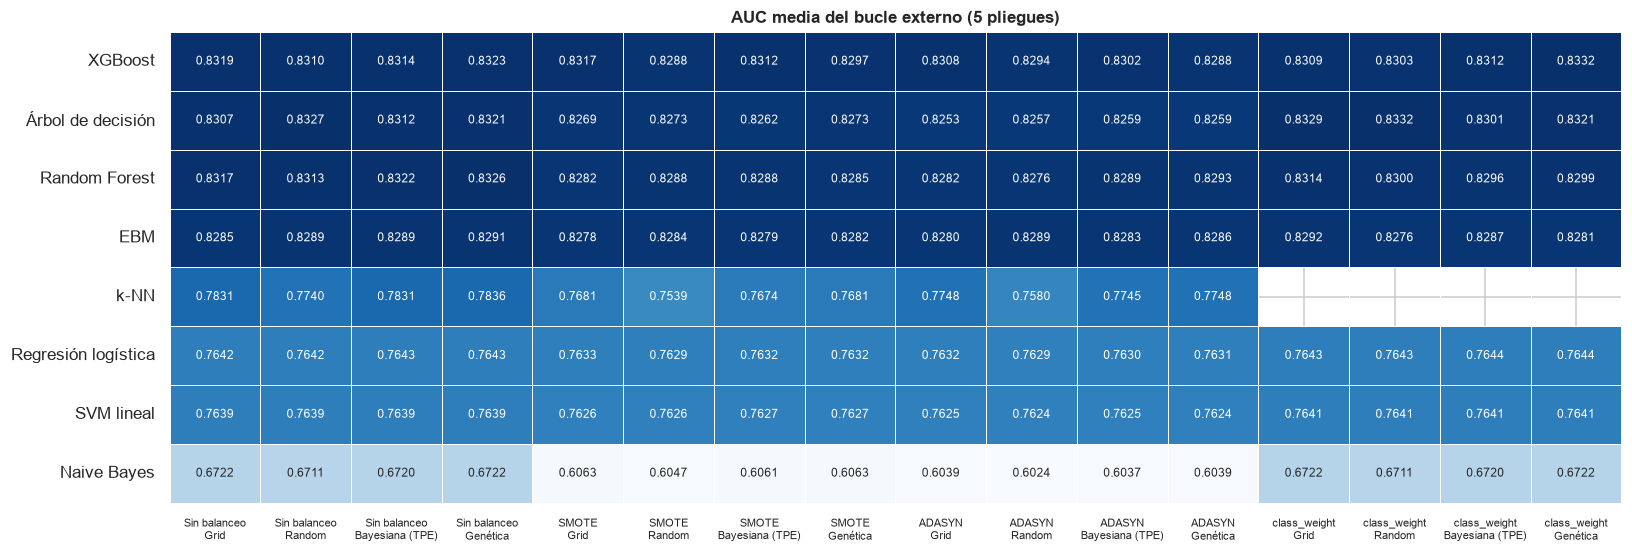

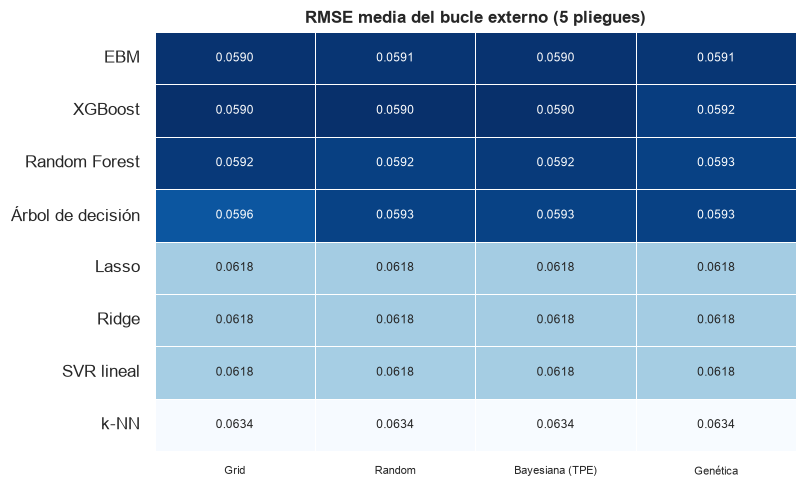

In [4]:
fig, ax = plt.subplots(figsize=(15, 5.2))
graficos.mapa_corridas(tabla, 'clasificacion', ax=ax)
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(7.5, 4.6))
graficos.mapa_corridas(tabla, 'regresion', ax=ax)
plt.tight_layout()
plt.show()

## La mejor combinación de cada modelo

Es la que se lleva a la evaluación en prueba y a la comparación estadística. Se elige por la
métrica media del bucle externo, sin mirar la prueba.

In [5]:
def tabla_mejores(tarea):
    m = analisis.mejores_por_modelo(tabla, tarea)
    return pd.DataFrame({
        'modelo': m['modelo'].map(NOMBRES_MODELO), 'balanceo': m['balanceo'], 'optimizador': m['optimizador'],
        ('AUC' if tarea == 'clasificacion' else 'RMSE') + ' externa': m['metrica'], 'desv. entre pliegues': m['desv_ext'],
        'minutos': m['tiempo_total_s'] / 60,
        'hiperparámetros finales': m['hiperparametros'].apply(
            lambda h: ', '.join(f'{k.split("__", 1)[1]}={v:.4g}' if isinstance(v, float) else f'{k.split("__", 1)[1]}={v}'
                                for k, v in h.items()))}).set_index('modelo')

mejores_clf, mejores_reg = tabla_mejores('clasificacion'), tabla_mejores('regresion')
display(mejores_clf)
display(mejores_reg)

,balanceo,optimizador,AUC externa,desv. entre pliegues,minutos,hiperparámetros finales
modelo,,,,,,
XGBoost,class_weight,genetica,0.8332,0.0049,8.8883,"n_estimators=145, max_depth=6, learning_rate=0.003304, subsample=0.8081, colsample_bytree=0.9683, reg_lambda=0.8792,..."
Árbol de decisión,class_weight,random,0.8332,0.0021,1.8027,"ccp_alpha=0.0003897, criterion=gini, max_depth=22, min_samples_leaf=7"
Random Forest,ninguno,genetica,0.8326,0.0029,20.8890,"max_depth=32, max_features=0.5, min_samples_leaf=11, n_estimators=300"
EBM,class_weight,grid,0.8292,0.0037,18.6728,"interactions=0, learning_rate=0.008, max_leaves=2, min_samples_leaf=100, outer_bags=8"
k-NN,ninguno,genetica,0.7836,0.0072,34.7139,"n_neighbors=600, weights=distance, p=1"
Regresión logística,class_weight,genetica,0.7644,0.0047,3.0827,"C=0.05631, l1_ratio=1"
SVM lineal,class_weight,grid,0.7641,0.0044,2.0670,C=0.001083
Naive Bayes,ninguno,grid,0.6722,0.0119,0.6732,var_smoothing=0.001


,balanceo,optimizador,RMSE externa,desv. entre pliegues,minutos,hiperparámetros finales
modelo,,,,,,
XGBoost,ninguno,bayesiana,0.0590,0.0004,10.3978,"n_estimators=512, max_depth=2, learning_rate=0.02361, subsample=0.8025, colsample_bytree=0.7268, reg_lambda=0.2158, ..."
EBM,ninguno,grid,0.0590,0.0004,26.5974,"interactions=0, learning_rate=0.008, max_leaves=3, min_samples_leaf=20, outer_bags=8"
Random Forest,ninguno,grid,0.0592,0.0004,16.0544,"max_depth=8, max_features=0.5, min_samples_leaf=50, n_estimators=300"
Árbol de decisión,ninguno,genetica,0.0593,0.0004,3.7207,"max_depth=13, min_samples_leaf=101, ccp_alpha=1.811e-06"
Lasso,ninguno,genetica,0.0618,0.0005,6.6994,alpha=0.0001087
Ridge,ninguno,genetica,0.0618,0.0005,1.4725,alpha=613.9
SVR lineal,ninguno,bayesiana,0.0618,0.0005,2.6889,"C=46.43, epsilon=0.0003846"
k-NN,ninguno,grid,0.0634,0.0004,24.9263,"n_neighbors=80, p=1, weights=distance"


In [6]:
mc = analisis.mejores_por_modelo(tabla, 'clasificacion')
mr = analisis.mejores_por_modelo(tabla, 'regresion')
display(Markdown(f"""
En **clasificación** el orden es {enumerar(f"{NOMBRES_MODELO[f.modelo]} ({dec(f.metrica)})" for f in mc.itertuples())}.
Los modelos basados en árboles encabezan la tabla con diferencias de milésimas entre sí; k-NN queda
{dec(mc.iloc[0]['metrica'] - mc.set_index('modelo').loc['knn', 'metrica'], 3)} por debajo del mejor y los dos lineales, unas
{dec(mc.iloc[0]['metrica'] - mc.set_index('modelo').loc['logistica', 'metrica'], 2)}. En **regresión**, {enumerar(f"{NOMBRES_MODELO[f.modelo]} ({dec(f.metrica)})" for f in mr.itertuples())}.
La desviación entre pliegues externos es de {dec(mc['desv_ext'].min(), 4)} a {dec(mc['desv_ext'].max(), 4)} de AUC: del mismo
orden que las diferencias entre los mejores modelos, que por eso se contrastan formalmente en la
sección de comparación estadística.
"""))


En **clasificación** el orden es XGBoost (0,8332), Árbol de decisión (0,8332), Random Forest (0,8326), EBM (0,8292), k-NN (0,7836), Regresión logística (0,7644), SVM lineal (0,7641) y Naive Bayes (0,6722).
Los modelos basados en árboles encabezan la tabla con diferencias de milésimas entre sí; k-NN queda
0,050 por debajo del mejor y los dos lineales, unas
0,07. En **regresión**, XGBoost (0,0590), EBM (0,0590), Random Forest (0,0592), Árbol de decisión (0,0593), Lasso (0,0618), Ridge (0,0618), SVR lineal (0,0618) y k-NN (0,0634).
La desviación entre pliegues externos es de 0,0021 a 0,0119 de AUC: del mismo
orden que las diferencias entre los mejores modelos, que por eso se contrastan formalmente en la
sección de comparación estadística.


### Todas las métricas como media ± desviación de los pliegues externos

La guía (§5.4) pide reportar cada métrica como media ± desviación estándar sobre los pliegues del
bucle externo. La tabla lo hace para la mejor combinación de cada modelo, con todas las métricas que
registra la tabla maestra (las de clasificación con umbral usan 0,5).

In [7]:
def media_desv(fila, metricas):
    return {m: f"{np.mean(fila['metricas_ext'][m]):.4f} ± {np.std(fila['metricas_ext'][m], ddof=1):.4f}"
            for m in metricas if m in fila['metricas_ext']}

pliegues_clf = pd.DataFrame({NOMBRES_MODELO[f['modelo']]: media_desv(f, ['auc', 'accuracy', 'precision', 'recall', 'f1', 'brier'])
                             for _, f in analisis.mejores_por_modelo(tabla, 'clasificacion').iterrows()}).T
pliegues_reg = pd.DataFrame({NOMBRES_MODELO[f['modelo']]: media_desv(f, ['rmse', 'mae', 'r2'])
                             for _, f in analisis.mejores_por_modelo(tabla, 'regresion').iterrows()}).T
display(pliegues_clf)
display(pliegues_reg)

,auc,accuracy,precision,recall,f1,brier
XGBoost,0.8332 ± 0.0049,0.7007 ± 0.0051,0.4506 ± 0.0039,0.9866 ± 0.0151,0.6186 ± 0.0038,0.2098 ± 0.0211
Árbol de decisión,0.8332 ± 0.0021,0.7009 ± 0.0051,0.4512 ± 0.0042,0.9976 ± 0.0021,0.6214 ± 0.0040,0.1664 ± 0.0030
Random Forest,0.8326 ± 0.0029,0.7838 ± 0.0037,0.6603 ± 0.0301,0.2521 ± 0.0212,0.3641 ± 0.0193,0.1307 ± 0.0012
EBM,0.8292 ± 0.0037,0.7311 ± 0.0047,0.4690 ± 0.0056,0.7008 ± 0.0134,0.5618 ± 0.0037,0.1724 ± 0.0032
k-NN,0.7836 ± 0.0072,0.7540 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.1667 ± 0.0004
Regresión logística,0.7644 ± 0.0047,0.6733 ± 0.0035,0.4026 ± 0.0030,0.6770 ± 0.0126,0.5049 ± 0.0039,0.1992 ± 0.0009
SVM lineal,0.7641 ± 0.0044,0.6723 ± 0.0022,0.4015 ± 0.0026,0.6770 ± 0.0151,0.5041 ± 0.0056,nan ± nan
Naive Bayes,0.6722 ± 0.0119,0.2882 ± 0.0068,0.2527 ± 0.0026,0.9670 ± 0.0074,0.4007 ± 0.0038,0.6550 ± 0.0244


,rmse,mae,r2
XGBoost,0.0590 ± 0.0004,0.0469 ± 0.0004,0.2274 ± 0.0086
EBM,0.0590 ± 0.0004,0.0471 ± 0.0004,0.2260 ± 0.0094
Random Forest,0.0592 ± 0.0004,0.0471 ± 0.0003,0.2230 ± 0.0077
Árbol de decisión,0.0593 ± 0.0004,0.0474 ± 0.0003,0.2200 ± 0.0074
Lasso,0.0618 ± 0.0005,0.0508 ± 0.0003,0.1518 ± 0.0099
Ridge,0.0618 ± 0.0005,0.0508 ± 0.0004,0.1514 ± 0.0098
SVR lineal,0.0618 ± 0.0005,0.0509 ± 0.0003,0.1509 ± 0.0103
k-NN,0.0634 ± 0.0004,0.0513 ± 0.0002,0.1087 ± 0.0043


## El efecto del balanceo

La guía (§5.1) pide comparar sin balanceo, SMOTE, ADASYN y `class_weight`. El balanceo actúa sobre
el entrenamiento de cada pliegue (SMOTE y ADASYN generan clientes sintéticos de riesgo alto;
`class_weight` pondera los errores de la clase minoritaria) y nunca sobre los datos de validación o
prueba. Para cada modelo se toma el mejor optimizador dentro de cada técnica.

In [8]:
clf = ok[ok['tarea'] == 'clasificacion'].copy()
mejor_por_bal = clf.loc[clf.groupby(['modelo', 'balanceo'])['metrica'].idxmax()]
efecto_auc = mejor_por_bal.pivot(index='modelo', columns='balanceo', values='metrica')
efecto_auc = efecto_auc[[b for b in graficos.NOMBRE_BALANCEO if b in efecto_auc.columns]]
delta = efecto_auc.sub(efecto_auc['ninguno'], axis=0).drop(columns='ninguno')
delta.index = [NOMBRES_MODELO[m] for m in delta.index]
display(delta.style.format('{:+.4f}', na_rep='no aplica').background_gradient(cmap='RdBu', vmin=-0.05, vmax=0.05))

matriz_bal = clf.pivot_table(index=['modelo', 'optimizador'], columns='balanceo', values='metrica')[
    ['ninguno', 'smote', 'adasyn']].dropna()
fr_bal = est.friedman(matriz_bal)
fr_bal['rangos_medios']

balanceo,smote,adasyn,class_weight
Árbol de decisión,-0.0054,-0.0068,+0.0005
EBM,-0.0007,-0.0002,+0.0001
k-NN,-0.0154,-0.0087,no aplica
Regresión logística,-0.0010,-0.0011,+0.0001
Naive Bayes,-0.0659,-0.0683,-0.0000
Random Forest,-0.0037,-0.0032,-0.0012
SVM lineal,-0.0012,-0.0014,+0.0002
XGBoost,-0.0006,-0.0015,+0.0009


balanceo
ninguno   1.0312
smote     2.3438
adasyn    2.6250
dtype: float64

In [9]:
def media_pliegues(fila, metrica):
    return float(np.mean(fila['metricas_ext'][metrica]))

for metrica in ('recall', 'precision', 'f1', 'brier'):
    mejor_por_bal[metrica] = mejor_por_bal.apply(lambda f: media_pliegues(f, metrica), axis=1)
umbral = mejor_por_bal[mejor_por_bal['modelo'].isin(['xgboost', 'random_forest', 'logistica', 'arbol'])]
compromiso = umbral.pivot_table(index='modelo', columns='balanceo', values=['recall', 'precision'])
compromiso.index = [NOMBRES_MODELO[m] for m in compromiso.index]
compromiso

precision                             recall               \
balanceo               adasyn class_weight ninguno  smote adasyn class_weight   
Árbol de decisión      0.4874       0.4512  0.6935 0.4879 0.5604       0.9976   
Regresión logística    0.4028       0.4026  0.6215 0.4016 0.6711       0.6770   
Random Forest          0.5142       0.4517  0.6603 0.5266 0.4606       0.9870   
XGBoost                0.5787       0.4506  0.0000 0.5783 0.3318       0.9866   

                                    
balanceo            ninguno  smote  
Árbol de decisión    0.2224 0.6023  
Regresión logística  0.2799 0.6726  
Random Forest        0.2521 0.4391  
XGBoost              0.0000 0.3290

In [10]:
dif_smote = delta['smote'].dropna()
dif_adasyn = delta['adasyn'].dropna()
dif_cw = delta['class_weight'].dropna()
rec = umbral.pivot_table(index='modelo', columns='balanceo', values='recall')
prob_max_sin = None
siempre_mejor = fr_bal['rangos_medios'].get('ninguno', 99) == 1.0
peor_smote = dif_smote.idxmin()
frase_umbral = (f"Con el umbral de 0,5, el recall de XGBoost pasa de {dec(rec.loc['xgboost', 'ninguno'], 3)} sin balanceo a "
                f"{dec(rec.loc['xgboost', 'class_weight'], 3)} con `class_weight`, a costa de la precisión")
if rec.loc['xgboost', 'ninguno'] == 0:
    frase_umbral += (': su mejor configuración sin balanceo (una tasa de aprendizaje muy baja con pocos árboles) '
                     'no asigna a ningún cliente una probabilidad mayor que 0,5, aunque los ordena tan bien como las demás')
display(Markdown(f"""
**`class_weight` no cambia el AUC** (de {dec(dif_cw.min(), 4, True)} a {dec(dif_cw.max(), 4, True)} frente a no balancear),
y **el sobremuestreo lo empeora**: SMOTE entre {dec(dif_smote.max(), 4, True)} y {dec(dif_smote.min(), 4, True)}, y ADASYN entre
{dec(dif_adasyn.max(), 4, True)} y {dec(dif_adasyn.min(), 4, True)}. {'En todos los bloques modelo × optimizador, no balancear es la mejor de las tres opciones (rango medio 1,00' if siempre_mejor else 'Friedman sobre los bloques modelo × optimizador da rangos medios ' + enumerar(f"{graficos.NOMBRE_BALANCEO[b]} {dec(v, 2)}" for b, v in fr_bal['rangos_medios'].items()) + ' ('}; Friedman {p_valor(fr_bal['p'])}). El AUC mide el orden de los clientes: reponderar
la clase minoritaria desplaza las probabilidades sin cambiar ese orden, y los clientes sintéticos de
SMOTE y ADASYN, interpolados entre vecinos de riesgo alto, añaden ruido en la frontera entre clases. El
caso extremo es {NOMBRES_MODELO.get(peor_smote, peor_smote)} ({dec(dif_smote.min(), 4, True)} con SMOTE): los clientes sintéticos alteran
las medias y varianzas por clase que el modelo estima.

**Donde sí actúa el balanceo es en las métricas que dependen del umbral.** {frase_umbral}. Es el mismo
efecto que se lograría moviendo el umbral de un modelo sin balancear: la elección no es de modelo
sino de punto de operación, y se trata con la calibración y el umbral en la sección de evaluación.
"""))


**`class_weight` no cambia el AUC** (de −0,0012 a +0,0009 frente a no balancear),
y **el sobremuestreo lo empeora**: SMOTE entre −0,0006 y −0,0659, y ADASYN entre
−0,0002 y −0,0683. Friedman sobre los bloques modelo × optimizador da rangos medios Sin balanceo 1,03, SMOTE 2,34 y ADASYN 2,62 (; Friedman p < 10⁻¹⁰). El AUC mide el orden de los clientes: reponderar
la clase minoritaria desplaza las probabilidades sin cambiar ese orden, y los clientes sintéticos de
SMOTE y ADASYN, interpolados entre vecinos de riesgo alto, añaden ruido en la frontera entre clases. El
caso extremo es Naive Bayes (−0,0659 con SMOTE): los clientes sintéticos alteran
las medias y varianzas por clase que el modelo estima.

**Donde sí actúa el balanceo es en las métricas que dependen del umbral.** Con el umbral de 0,5, el recall de XGBoost pasa de 0,000 sin balanceo a 0,987 con `class_weight`, a costa de la precisión: su mejor configuración sin balanceo (una tasa de aprendizaje muy baja con pocos árboles) no asigna a ningún cliente una probabilidad mayor que 0,5, aunque los ordena tan bien como las demás. Es el mismo
efecto que se lograría moviendo el umbral de un modelo sin balancear: la elección no es de modelo
sino de punto de operación, y se trata con la calibración y el umbral en la sección de evaluación.


## Coste de las corridas

In [11]:
horas = ok.pivot_table(index='modelo', columns='optimizador', values='tiempo_total_s', aggfunc='sum') / 3600
horas = horas[analisis.OPTIMIZADORES]
horas['total'] = horas.sum(axis=1)
horas.index = [NOMBRES_MODELO[m] for m in horas.index]
display(horas.sort_values('total', ascending=False))
total_guia = guia[guia['estado'] == 'ok']['tiempo_total_s'].sum() / 3600
caros = horas.drop(index=NOMBRES_MODELO['ebm'], errors='ignore').sort_values('total', ascending=False)
horas_ebm = horas.loc[NOMBRES_MODELO['ebm'], 'total'] if NOMBRES_MODELO['ebm'] in horas.index else None
display(Markdown(f"""
Las 140 corridas de la guía sumaron {dec(total_guia, 1)} horas de reloj en el equipo de 6 núcleos lógicos. Los
modelos más caros fueron {enumerar(f"{m} ({dec(h, 1)} h)" for m, h in caros['total'].head(3).items())}; los más
baratos, {enumerar(f"{m} ({dec(h * 60, 0)} min)" for m, h in caros['total'].tail(2).items())}.{(' Las 20 corridas de la EBM sumaron por sí solas ' + dec(horas_ebm, 1) + ' horas, sobre todo por el sobremuestreo (sección del modelo nuevo).') if horas_ebm else ''} En k-NN cada evaluación calcula
distancias entre todos los pares de clientes del pliegue; en Random Forest pesan los 300 árboles del
modelo final (la búsqueda ya usaba solo 100 gracias a la multi-fidelidad). La sección de cómputo mide
estos costes uno a uno y prueba alternativas más rápidas.
"""))

optimizador,grid,random,bayesiana,genetica,total
EBM,4.1947,4.3745,5.9366,4.9597,19.4655
Random Forest,2.5857,2.2791,3.0343,2.3189,10.2180
k-NN,1.3450,1.0057,2.7911,2.9965,8.1383
XGBoost,0.5280,0.7733,1.3344,1.6079,4.2435
Árbol de decisión,0.2086,0.2350,0.4377,0.4500,1.3312
Regresión logística,0.2260,0.2101,0.3068,0.2933,1.0362
SVM lineal,0.1736,0.1686,0.2490,0.2558,0.8469
Naive Bayes,0.0768,0.0769,0.1492,0.1489,0.4518
Lasso,0.1183,0.1203,0.0849,0.1117,0.4351
SVR lineal,0.0308,0.0281,0.0448,0.0436,0.1474



Las 140 corridas de la guía sumaron 26,9 horas de reloj en el equipo de 6 núcleos lógicos. Los
modelos más caros fueron Random Forest (10,2 h), k-NN (8,1 h) y XGBoost (4,2 h); los más
baratos, SVR lineal (9 min) y Ridge (5 min). Las 20 corridas de la EBM sumaron por sí solas 19,5 horas, sobre todo por el sobremuestreo (sección del modelo nuevo). En k-NN cada evaluación calcula
distancias entre todos los pares de clientes del pliegue; en Random Forest pesan los 300 árboles del
modelo final (la búsqueda ya usaba solo 100 gracias a la multi-fidelidad). La sección de cómputo mide
estos costes uno a uno y prueba alternativas más rápidas.


## Estabilidad de los hiperparámetros entre pliegues

Si los hiperparámetros ganadores cambian mucho de un pliegue externo a otro, la búsqueda es
inestable o el óptimo es una meseta plana donde muchas configuraciones rinden igual. La tabla cuenta,
para cada optimizador, cuántas configuraciones distintas eligieron los 5 pliegues de cada corrida.

In [12]:
def distintas(params):
    return len({tuple(sorted((k, round(v, 6) if isinstance(v, float) else v) for k, v in p.items())) for p in params})

ok_est = ok.assign(configuraciones_distintas=ok['params_por_pliegue'].apply(distintas))
estabilidad = ok_est.groupby(['tarea', 'optimizador'])['configuraciones_distintas'].agg(['mean', 'min', 'max']).reindex(
    analisis.OPTIMIZADORES, level='optimizador')
estabilidad

mean  min  max
tarea         optimizador                 
clasificacion grid        2.7742    1    5
              random      2.9677    1    5
              bayesiana   4.2258    1    5
              genetica    3.4194    1    5
regresion     grid        2.3750    1    4
              random      2.2500    1    4
              bayesiana   3.8750    2    5
              genetica    4.0000    1    5

In [13]:
e = estabilidad.xs('clasificacion')
display(Markdown(f"""
En clasificación, Grid y Random son los más estables ({dec(e.loc['grid', 'mean'], 1)} y {dec(e.loc['random', 'mean'], 1)}
configuraciones distintas de media en 5 pliegues): los dos evalúan el **mismo conjunto de candidatos**
en todos los pliegues (la rejilla, o la misma muestra aleatoria porque la semilla es fija), así que
solo cambia cuál gana. La bayesiana ({dec(e.loc['bayesiana', 'mean'], 1)}) y la genética ({dec(e.loc['genetica', 'mean'], 1)})
adaptan sus propuestas a los puntajes de cada pliegue y rara vez visitan los mismos puntos. Que
configuraciones distintas den la misma métrica externa (la desviación entre pliegues es de
milésimas) indica que el óptimo es una meseta: lo que importa es llegar a ella, no el punto exacto,
y eso es coherente con que los cuatro métodos terminen en el mismo nivel.
"""))


En clasificación, Grid y Random son los más estables (2,8 y 3,0
configuraciones distintas de media en 5 pliegues): los dos evalúan el **mismo conjunto de candidatos**
en todos los pliegues (la rejilla, o la misma muestra aleatoria porque la semilla es fija), así que
solo cambia cuál gana. La bayesiana (4,2) y la genética (3,4)
adaptan sus propuestas a los puntajes de cada pliegue y rara vez visitan los mismos puntos. Que
configuraciones distintas den la misma métrica externa (la desviación entre pliegues es de
milésimas) indica que el óptimo es una meseta: lo que importa es llegar a ella, no el punto exacto,
y eso es coherente con que los cuatro métodos terminen en el mismo nivel.
